# Linear Discriminant Analysis (LDA)

В этом ноутбуке посмотрим:
- LDA использует метки → это supervised метод;
- сравним проекции PCA vs LDA в 2D;
- проверим ограничение `n_components <= n_classes − 1`;
- сравним качество классификации **до** и **после** LDA.

## 1. Импорты и данные

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

In [2]:
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['class'] = [target_names[i] for i in y]
print('Shape:', X.shape, '| Классы:', list(target_names))
df.head()

Shape: (178, 13) | Классы: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 2. PCA в 2D — без учёта меток

PCA ищет направления **наибольшей дисперсии**, не зная, кто к какому классу относится.

In [4]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)

print('Объяснённая дисперсия:', pca.explained_variance_ratio_.round(3))

Объяснённая дисперсия: [0.357 0.192]


## 3. LDA в 2D — с метками классов

LDA получает на вход `y`, поэтому это **supervised** метод. Он строит оси так, чтобы **между-классовая** дисперсия была максимальной, а **внутри-классовая** — минимальной.

In [5]:
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_s, y_train)

print('Объяснённая дисперсия LDA:', lda.explained_variance_ratio_.round(3))

Объяснённая дисперсия LDA: [0.667 0.333]


### Сравним PCA и LDA на одном графике

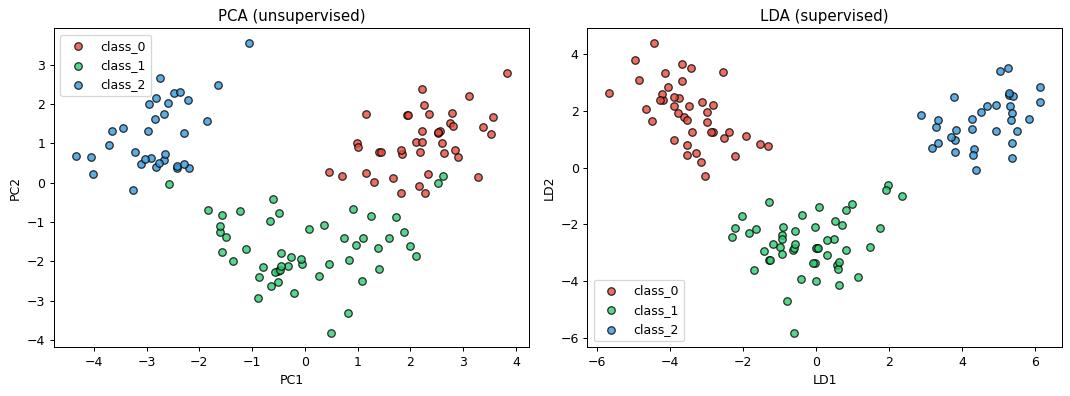

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#e74c3c', '#2ecc71', '#3498db']

for cls, color in zip(np.unique(y_train), colors):
    axes[0].scatter(X_train_pca[y_train == cls, 0], X_train_pca[y_train == cls, 1], c=color, label=target_names[cls], alpha=0.8, edgecolor='k')
    axes[1].scatter(X_train_lda[y_train == cls, 0], X_train_lda[y_train == cls, 1], c=color, label=target_names[cls], alpha=0.8, edgecolor='k')

axes[0].set_title('PCA (unsupervised)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend()
axes[1].set_title('LDA (supervised)')
axes[1].set_xlabel('LD1'); axes[1].set_ylabel('LD2'); axes[1].legend()
plt.tight_layout(); plt.show()

На графике LDA классы разделены **заметно чище** — потому что метод знает про метки и оптимизирует именно разделимость.

## 4. Ограничение LDA: `n_components <= n_classes − 1`

У нас 3 класса → LDA максимум даст **2 компоненты**. Попробуем запросить 3 — поймаем ошибку.

In [7]:
n_classes = len(np.unique(y_train))
print(f'Классов: {n_classes} → max n_components = {n_classes - 1}')

try:
    LDA(n_components=3).fit(X_train_s, y_train)
except ValueError as e:
    print('Ошибка sklearn:', e)

Классов: 3 → max n_components = 2
Ошибка sklearn: n_components cannot be larger than min(n_features, n_classes - 1).


## 5. Качество классификации: до и после LDA

Обучим простую логистическую регрессию на:
1. исходных 13 признаках;
2. на 2 LDA-компонентах.

In [8]:
def evaluate(X_tr, X_te, y_tr, y_te, label):
    clf = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    return {
        'name': label,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, average='macro'),
        'recall':    recall_score(y_te, y_pred, average='macro'),
        'f1':        f1_score(y_te, y_pred, average='macro'),
        'cm':        confusion_matrix(y_te, y_pred),
    }

res_before = evaluate(X_train_s, X_test_s, y_train, y_test, 'До LDA (13 признаков)')

X_test_lda = lda.transform(X_test_s)
res_after  = evaluate(X_train_lda, X_test_lda, y_train, y_test, 'После LDA (2 компоненты)')

pd.DataFrame([res_before, res_after])[['name','accuracy','precision','recall','f1']]

,name,accuracy,precision,recall,f1
0,До LDA (13 признаков),0.981481,0.982456,0.984127,0.982861
1,После LDA (2 компоненты),0.981481,0.982456,0.984127,0.982861


### Confusion matrix — до и после

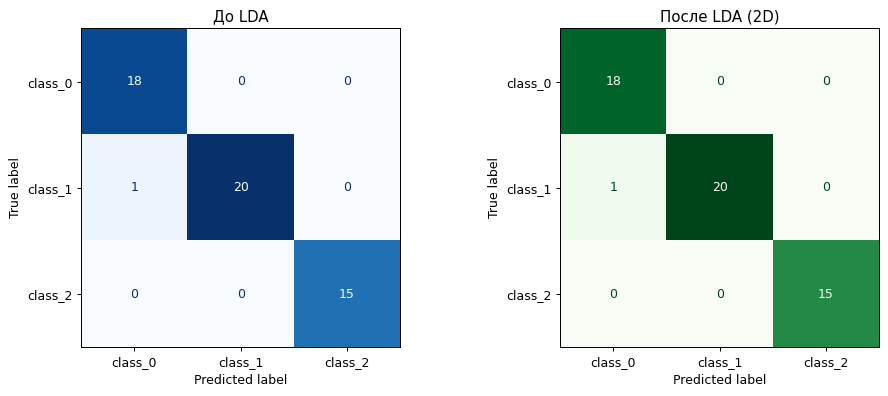

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(res_before['cm'], display_labels=target_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('До LDA')

ConfusionMatrixDisplay(res_after['cm'], display_labels=target_names).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('После LDA (2D)')

plt.tight_layout(); plt.show()

### Bar chart метрик

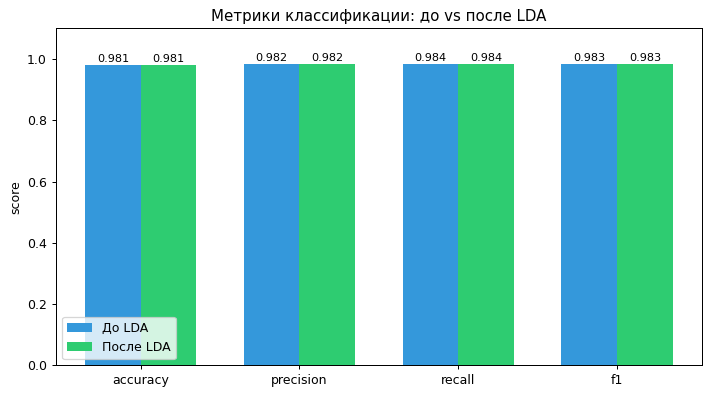

In [10]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
vals_before = [res_before[m] for m in metrics]
vals_after  = [res_after[m]  for m in metrics]

x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, vals_before, w, label='До LDA', color='#3498db')
b2 = ax.bar(x + w/2, vals_after,  w, label='После LDA', color='#2ecc71')

for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1); ax.set_ylabel('score')
ax.set_title('Метрики классификации: до vs после LDA')
ax.legend(); plt.tight_layout(); plt.show()

#**Общий итог:**

- **LDA — supervised**: на вход нужен `y`, в отличие от PCA.
- **PCA** ищет направления максимальной дисперсии, **LDA** — направления максимальной разделимости классов → на 2D-графике LDA классы выглядят аккуратнее.
- **Ограничение**: `n_components <= n_classes - 1`. Для 3 классов — максимум 2 компоненты.
- Сжав 13 признаков до **всего 2 LDA-компонент**, мы получили качество классификации не хуже (а часто и лучше), чем на исходных данных — LDA сохраняет именно ту информацию, что нужна для разделения классов.